# 02 - SU2 vs Kaggle Comparison

This notebook extends the baseline study in two steps:

1. Validate that the dense SU2 dataset is sufficiently close to the original Kaggle dataset.
2. Re-run the same Cp surrogate modeling pipeline on the dense SU2 dataset to test whether the Random Forest result remains strong under denser AoA coverage.

## 1. Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## 2. Connect The Notebook To The Project

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from cfd_ml.data import load_rae2822_surface_data
from cfd_ml.paths import (
    DENSE_RAE2822_CASE_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    RAE2822_CASE_DIR,
)

## 3. Compare Dataset Coverage

In [3]:
original_df = load_rae2822_surface_data(RAE2822_CASE_DIR)
dense_df = load_rae2822_surface_data(DENSE_RAE2822_CASE_DIR)

dense_rows_per_aoa = dense_df.groupby("AoA").size()

coverage_df = pd.DataFrame([
    {
        "dataset": "Kaggle original",
        "rows": len(original_df),
        "aoa_cases": original_df["AoA"].nunique(),
        "aoa_min": original_df["AoA"].min(),
        "aoa_max": original_df["AoA"].max(),
        "rows_per_aoa": int(original_df.groupby("AoA").size().iloc[0]),
    },
    {
        "dataset": "Dense SU2",
        "rows": len(dense_df),
        "aoa_cases": dense_df["AoA"].nunique(),
        "aoa_min": dense_df["AoA"].min(),
        "aoa_max": dense_df["AoA"].max(),
        "rows_per_aoa": int(dense_rows_per_aoa.iloc[0]),
    },
])

display(coverage_df)

print("Dense SU2 rows:", len(dense_df))
print("Dense SU2 AoA cases:", dense_df["AoA"].nunique())
print("Dense SU2 AoA range:", dense_df["AoA"].min(), "to", dense_df["AoA"].max())
print("Dense SU2 rows per AoA: min =", dense_rows_per_aoa.min(), "max =", dense_rows_per_aoa.max())

dense_rows_per_aoa.to_frame("surface_points")


,dataset,rows,aoa_cases,aoa_min,aoa_max,rows_per_aoa
0,Kaggle original,4032,21,0.0,20.0,192
1,Dense SU2,7872,41,0.0,20.0,192


Dense SU2 rows: 7872
Dense SU2 AoA cases: 41
Dense SU2 AoA range: 0.0 to 20.0
Dense SU2 rows per AoA: min = 192 max = 192


,surface_points
AoA,
0.0,192
0.5,192
1.0,192
1.5,192
2.0,192
2.5,192
3.0,192
3.5,192
4.0,192


## 4. Load Overlap Comparison Summary

In [4]:
summary_path = METRICS_DIR / "rae2822_dense_su2_vs_kaggle_summary.csv"
if not summary_path.exists():
    raise FileNotFoundError(
        "Run python3 scripts/compare_rae2822_dense_to_kaggle.py first."
    )

comparison_df = pd.read_csv(summary_path)
comparison_df

,AoA,original_csv,dense_csv,row_count_original,row_count_dense,pointid_match,xy_match,cp_source,cp_mae,cp_rmse,cp_max_abs,cp_r2
0,0.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.000474,0.000493,0.000763,0.999999
1,1.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.000592,0.000657,0.001763,0.999998
2,2.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.000700,0.001212,0.010228,0.999996
3,3.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.000956,0.001964,0.016114,0.999992
4,4.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.001804,0.003758,0.033282,0.999975
5,5.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.002520,0.007160,0.072244,0.999914
6,6.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.003013,0.008307,0.079567,0.999887
7,7.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.003276,0.009583,0.091636,0.999850
8,8.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.004397,0.017384,0.177648,0.999500
9,9.0,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,/Users/pun/Desktop/CFD-ML/CFD-Machine-learning...,192,192,True,True,native,0.005555,0.022558,0.238362,0.999112


## 5. Plot Cp Error By AoA

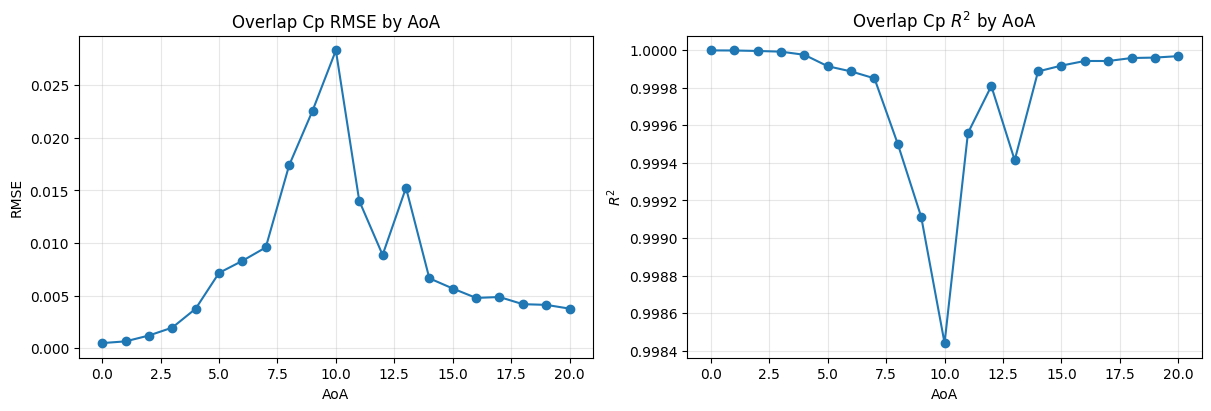

Max overlap RMSE: 0.0283038366131201
Min overlap R2: 0.9984406760032404


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(comparison_df["AoA"], comparison_df["cp_rmse"], marker="o")
axes[0].set_title("Overlap Cp RMSE by AoA")
axes[0].set_xlabel("AoA")
axes[0].set_ylabel("RMSE")
axes[0].grid(True, alpha=0.3)

axes[1].plot(comparison_df["AoA"], comparison_df["cp_r2"], marker="o")
axes[1].set_title("Overlap Cp $R^2$ by AoA")
axes[1].set_xlabel("AoA")
axes[1].set_ylabel("$R^2$")
axes[1].grid(True, alpha=0.3)

plt.show()

print("Max overlap RMSE:", comparison_df["cp_rmse"].max())
print("Min overlap R2:", comparison_df["cp_r2"].min())

## 6. Visual Check At One AoA

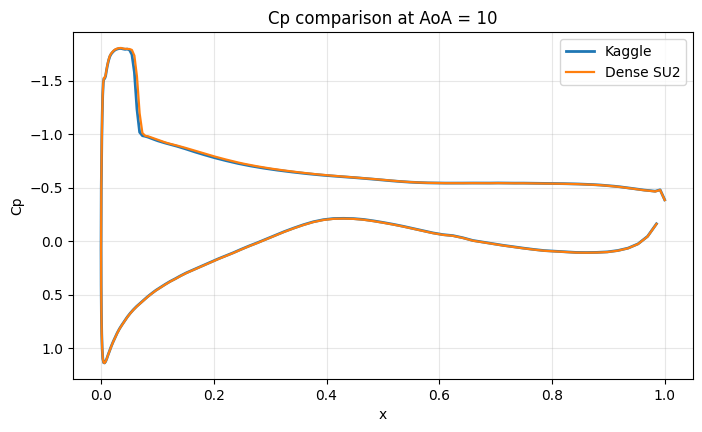

In [6]:
representative_aoa = 10.0

original_case = pd.read_csv(RAE2822_CASE_DIR / f"{representative_aoa:g}" / "surface_flow.csv", skipinitialspace=True)
dense_case = pd.read_csv(DENSE_RAE2822_CASE_DIR / f"{representative_aoa:g}" / "surface_flow.csv", skipinitialspace=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(original_case["x"], original_case["Pressure_Coefficient"], label="Kaggle", linewidth=2)
ax.plot(dense_case["x"], dense_case["Pressure_Coefficient"], label="Dense SU2", linewidth=1.6)
ax.invert_yaxis()
ax.set_title(f"Cp comparison at AoA = {representative_aoa:g}")
ax.set_xlabel("x")
ax.set_ylabel("Cp")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 7. Build Dense SU2 Modeling Inputs

In [4]:
features = ["x", "y", "sin_AoA", "cos_AoA"]
target = "Pressure_Coefficient"

X_dense = dense_df[features]
y_dense = dense_df[target]
groups_dense = dense_df["AoA"]

print("Dense feature matrix shape:", X_dense.shape)
print("Dense target shape:", y_dense.shape)
print("Dense groups shape:", groups_dense.shape)
print("Features:", features)
print("Target:", target)

X_dense.head()

Dense feature matrix shape: (7872, 4)
Dense target shape: (7872,)
Dense groups shape: (7872,)
Features: ['x', 'y', 'sin_AoA', 'cos_AoA']
Target: Pressure_Coefficient


,x,y,sin_AoA,cos_AoA
0,0.985397,0.000943,0.0,1.0
1,0.969573,0.001489,0.0,1.0
2,0.952680,0.001679,0.0,1.0
3,0.934996,0.001511,0.0,1.0
4,0.916822,0.000923,0.0,1.0


## 8. Define Leave-One_AoA-Out Validation

In [5]:
from sklearn.model_selection import LeaveOneGroupOut

logo_dense = LeaveOneGroupOut()
dense_splits = list(logo_dense.split(X_dense, y_dense, groups_dense))

print("Number of dense folds:", len(dense_splits))
print("Unique AoA groups:", groups_dense.nunique())

first_train_idx, first_test_idx = dense_splits[0]
print("First held-out AoA:", groups_dense.iloc[first_test_idx].unique())
print("Train rows in first fold:", len(first_train_idx))
print("Test rows in first fold:", len(first_test_idx))


Number of dense folds: 41
Unique AoA groups: 41
First held-out AoA: [0.]
Train rows in first fold: 7680
Test rows in first fold: 192


## 9. Reuse The Baselie Evaluation Logic

In [6]:
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X, y, groups, reference_df):
    splitter = LeaveOneGroupOut()
    fold_scores = []
    fold_predictions = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        fold_model = clone(model)
        fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])

        y_true = y.iloc[test_idx]
        y_pred = fold_model.predict(X.iloc[test_idx])

        test_groups = groups.iloc[test_idx].unique()
        if len(test_groups) != 1:
            raise ValueError(f"Expected one held-out AoA per fold, got {test_groups}")

        test_aoa = float(test_groups[0])

        fold_scores.append({
            "fold": fold,
            "AoA": test_aoa,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2": r2_score(y_true, y_pred),
        })

        prediction_frame = reference_df.iloc[test_idx][["AoA", "x", "y"]].copy()
        prediction_frame["y_true"] = y_true.to_numpy()
        prediction_frame["y_pred"] = y_pred
        fold_predictions.append(prediction_frame)

    return pd.DataFrame(fold_scores), pd.concat(fold_predictions, ignore_index=True)


## 10. Evaluate All Baseline Models On Dense SU2

In [9]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [10]:
dense_models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Polynomial ridge d2": make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        Ridge(alpha=1.0),
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=120,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient boosting": GradientBoostingRegressor(
        n_estimators=160,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

dense_all_scores = []
dense_all_predictions = {}

for model_name, model in dense_models.items():
    print(f"Evaluating {model_name}...")
    scores, predictions = evaluate_model(
        model,
        X_dense,
        y_dense,
        groups_dense,
        reference_df=dense_df,
    )
    scores["model"] = model_name
    dense_all_scores.append(scores)
    dense_all_predictions[model_name] = predictions

dense_scores_df = pd.concat(dense_all_scores, ignore_index=True)
dense_scores_df.head()

Evaluating Mean baseline...
Evaluating Linear regression...
Evaluating Polynomial ridge d2...
Evaluating Random forest...
Evaluating Gradient boosting...


,fold,AoA,MAE,RMSE,R2,model
0,1,0.0,0.319923,0.438179,-0.130223,Mean baseline
1,2,0.5,0.347606,0.454890,-0.087908,Mean baseline
2,3,1.0,0.389113,0.484084,-0.048198,Mean baseline
3,4,1.5,0.436375,0.525769,-0.019912,Mean baseline
4,5,2.0,0.488566,0.578870,-0.004682,Mean baseline


In [11]:
dense_summary_df = (
    dense_scores_df
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        RMSE_std=("RMSE", "std"),
    )
    .sort_values("RMSE_mean")
)

dense_summary_df


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest,0.014462,0.037155,0.995163,0.024286
Gradient boosting,0.107201,0.149635,0.943501,0.041941
Polynomial ridge d2,0.347953,0.445585,0.522815,0.050127
Linear regression,0.400578,0.515257,0.383693,0.062880
Mean baseline,0.562090,0.673413,-0.015698,0.091378


## 11. Tune The best Dense SU2 Models

In [12]:
from cfd_ml.tuning import build_cp_tuning_specs, tune_randomized_search_specs
from sklearn.model_selection import LeaveOneGroupOut

dense_tuning_specs = build_cp_tuning_specs(random_state=42)

dense_tuning_specs = {
    name: dense_tuning_specs[name]
    for name in [
        "Random forest tuned",
        "Gradient boosting tuned",
    ]
}

dense_tuning_results_df, dense_tuned_models = tune_randomized_search_specs(
    dense_tuning_specs,
    X_dense,
    y_dense,
    cv=LeaveOneGroupOut(),
    groups=groups_dense,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    search_n_jobs=1,
)

dense_tuning_results_df


Tuning Random forest tuned...
Tuning Gradient boosting tuned...


,model,best_score,best_rmse,best_params,n_iter,cv_splits,scoring
0,Random forest tuned,-0.032537,0.032537,"{'n_estimators': 300, 'min_samples_split': 2, ...",24,41,neg_root_mean_squared_error
1,Gradient boosting tuned,-0.058860,0.058860,"{'subsample': 0.75, 'n_estimators': 220, 'min_...",24,41,neg_root_mean_squared_error


In [ ]:
dense_tuned_scores = []
dense_tuned_predictions = {}

for model_name, model in dense_tuned_models.items():
    print(f"Evaluating {model_name}...")
    scores, predictions = evaluate_model(
        model,
        X_dense,
        y_dense,
        groups_dense,
        reference_df=dense_df,
    )
    scores["model"] = model_name
    dense_tuned_scores.append(scores)
    dense_tuned_predictions[model_name] = predictions

dense_tuned_scores_df = pd.concat(dense_tuned_scores, ignore_index=True)

dense_tuned_summary_df = (
    dense_tuned_scores_df
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        RMSE_std=("RMSE", "std"),
    )
    .sort_values("RMSE_mean")
)

dense_tuned_summary_df

Evaluating Random forest tuned...
Evaluating Gradient boosting tuned...


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned,0.011394,0.032537,0.995949,0.025448
Gradient boosting tuned,0.035078,0.058860,0.990157,0.026563
